# First use the HPLC_molecule_creation script if it is the frist analysis load

## Load Molecules

In [1]:
from chromhandler import Handler, Molecule, Protein, to_enzymeml
from pathlib import Path
import numpy as np
from utility import plot_replicates

# create list to add molecules to
molecules = []

# define path to the calibration molecules
molecule_dir = Path("result/calib_molecules/")

# loop over all the json files in the calibration molecules folder
# and create molecule objects
for molecule_path in molecule_dir.glob("*.json"):
    molecule = Molecule.read_json(molecule_path)
    molecules.append(molecule)

print(f"Loaded {len(molecules)} with IDs {[m.id for m in molecules]}")


Loaded 10 with IDs ['ATP', 'AMP', 'GMP', 'GTP', 'ADP', 'Gua', 'TrisHCL', 'Ado', 'GDP', 'MgCl2']


## Load Proteins

In [2]:
proteins = []

for protein_path in Path("result/proteins").glob("*.json"):
    protein = Protein.read_json(protein_path)
    proteins.append(protein)

print(f"Loaded {len(proteins)} with names {[p.name for p in proteins]}")

Loaded 4 with names ['ScADK', 'EaGK', 'tmmcGAS', 'EbPPK']


## Load Metadata

The spreadsheet `metadata_v2.xlsx` defines the initial concentrations of all molecules present in the respective assay. 
Products should be added with a concentration of 0. Empty cells are not added to the analyzer.

In [3]:
import pandas as pd
from pathlib import Path

# load metadata as dataframe
metadata_path = "input/metadata_v2.xlsx"
metadata_df = pd.read_excel(metadata_path)

# set 'experiment_name' as index
metadata_df.set_index("experiment_name", inplace=True)

metadata_df

,reaction_vol [mL],temperature,pH,TrisHCL,ScADK,EbPPK,tmmcGAS,EaGK,Ado,AMP,ADP,ATP,GMP,GDP,GTP,Gua,MgCl2
experiment_name,,,,,,,,,,,,,,,,,
20250407_ScADK_EbPPK_tmmcGAS,1,37,8,50000,0.00057,0.00106,0.00072,NaN,5,0.1,0,0,5.0,0.0,0.0,NaN,10
20250619_ScADK_EaGK_EbPPK_tmmcGAS,1,37,8,50000,0.00057,0.00072,NaN,0.00106,5,0.1,0,0,0.1,NaN,NaN,5.0,10
20241030 Ado ATP 1,1,37,8,50000,0.00057,0.00106,0.00072,NaN,5,0.1,0,0,5.0,0.0,0.0,NaN,10
20241030 Ado ATP 2,1,37,8,50000,0.00057,0.00106,0.00072,NaN,5,0.1,0,0,5.0,0.0,0.0,NaN,10
20241030 Ado ATP 3,1,37,8,50000,0.00057,0.00106,0.00072,NaN,5,0.1,0,0,5.0,0.0,0.0,NaN,10


# Process timecours data 

In [4]:
sample_dir = Path("data/time_sample/20241030 Ado ATP")

# loop over all the time samples and create the ChromAnalyzer objects
handlers = []
for time_samples in sample_dir.iterdir():
    path = str(time_samples)
    analyzer = Handler.read_agilent(
        path=path,
        ph=metadata_df.loc[str(time_samples.name), "pH"],
        temperature=metadata_df.loc[str(time_samples.name), "temperature"],
        mode="timecourse",
    )

    # add molecule data to the analyzer
    for molecule in molecules:
        init_conc = metadata_df.loc[str(time_samples.name), molecule.id]

        # set constant molecules (concentration does not change over time)
        if molecule.id in ["MgCl2", "TrisHCL"]:
            molecule.constant = True

        # if init conc not nan, add to analyzer
        if not np.isnan(init_conc):
            analyzer.add_molecule(
                molecule,
                init_conc=metadata_df.loc[str(time_samples.name), molecule.id],
                conc_unit="umol / L",
            )

    # add protein data to the analyzer
    for protein in proteins:
        init_conc = metadata_df.loc[str(time_samples.name), protein.name]

        # if init conc not nan, add to analyzer
        if not np.isnan(init_conc):
            analyzer.add_protein(
                protein,
                init_conc=metadata_df.loc[str(time_samples.name), protein.name],
                conc_unit="umol / L",
            )

    analyzer.assign_all_peaks()

    handlers.append(analyzer)

              🎯 Peak Assignment Summary of 20241030 Ado ATP 1               
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Molecule                      ┃   Status   ┃ Details                      ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ ATP (5'-Atp)                  │ ✅ Success │ (8/8) peaks assigned         │
│ AMP (Adenosine Monophosphate) │ ✅ Success │ (8/8) peaks assigned         │
│ GMP (Guanosine Monophosphate) │ ❌ Failed  │ (0/8) peaks at 1.9 ± 0.4 min │
│ GTP (Guanosine Triphosphate)  │ ❌ Failed  │ (0/8) peaks at 7.9 ± 0.4 min │
│ ADP (5'-Adp)                  │ ✅ Success │ (8/8) peaks assigned         │
│ Ado (Adenosine)               │ ✅ Success │ (8/8) peaks assigned         │
│ GDP (Guanosine Diphosphate)   │ ✅ Success │ (8/8) peaks assigned         │
└───────────────────────────────┴────────────┴──────────────────────────────┘

              🎯 Peak Assignment Summary of 20241030 Ado ATP 3               
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Molecule                      ┃   Status   ┃ Details                      ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ ATP (5'-Atp)                  │ ✅ Success │ (8/8) peaks assigned         │
│ AMP (Adenosine Monophosphate) │ ✅ Success │ (8/8) peaks assigned         │
│ GMP (Guanosine Monophosphate) │ ❌ Failed  │ (0/8) peaks at 1.9 ± 0.4 min │
│ GTP (Guanosine Triphosphate)  │ ❌ Failed  │ (0/8) peaks at 7.9 ± 0.4 min │
│ ADP (5'-Adp)                  │ ✅ Success │ (8/8) peaks assigned         │
│ Ado (Adenosine)               │ ✅ Success │ (8/8) peaks assigned         │
│ GDP (Guanosine Diphosphate)   │ ✅ Success │ (8/8) peaks assigned         │
└───────────────────────────────┴────────────┴──────────────────────────────┘

              🎯 Peak Assignment Summary of 20241030 Ado ATP 2               
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Molecule                      ┃   Status   ┃ Details                      ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ ATP (5'-Atp)                  │ ✅ Success │ (8/8) peaks assigned         │
│ AMP (Adenosine Monophosphate) │ ✅ Success │ (8/8) peaks assigned         │
│ GMP (Guanosine Monophosphate) │ 🟡 Partial │ (1/8) peaks assigned         │
│ GTP (Guanosine Triphosphate)  │ ❌ Failed  │ (0/8) peaks at 7.9 ± 0.4 min │
│ ADP (5'-Adp)                  │ ✅ Success │ (8/8) peaks assigned         │
│ Ado (Adenosine)               │ ✅ Success │ (8/8) peaks assigned         │
│ GDP (Guanosine Diphosphate)   │ ✅ Success │ (8/8) peaks assigned         │
└───────────────────────────────┴────────────┴──────────────────────────────┘

## Create EnzymeML Document including 3 replicates



In [5]:
import pyenzyme as pe

# add the metadata to the timecourse data
timecourse_enzymeML = to_enzymeml(
    document_name="MjNK_20mg_L_HEPES_50mM_NaCl_150mM",
    handlers=handlers,
    calculate_concentration=True,
    extrapolate=False,
)

# add vessel
vessel = pe.Vessel(
    id="v1",
    name="Eppendorf Tube",
    volume="1",
    unit="ml",
)
timecourse_enzymeML.vessels = [vessel]

# identify replicates
timecourse_enzymeML = pe.group_measurements(timecourse_enzymeML, attribute="prepared")

# show summary of document
pe.summary(timecourse_enzymeML)

# save the enzymeML document to file
pe.write_enzymeml(
    timecourse_enzymeML, f"result/enzymeML/{timecourse_enzymeML.name}.json"
)

📋 EnzymeML Document Summary

╭─ 📄 Document Overview ──────────────────────────────────────────────────────────────────────────────────────────╮
│ Name: MjNK_20mg_L_HEPES_50mM_NaCl_150mM                                                                         │
│ Version: 2                                                                                                      │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

    📊 Component Counts                                                                                  
┏━━━━━━━━━━━━━━━━━┳━━━━━━━┓                                                                              
┃ Component       ┃ Count ┃                                                                              
┡━━━━━━━━━━━━━━━━━╇━━━━━━━┩                                                                              
│ Vessels         │     1 │                                                                              
│ Proteins        │     3 │                                                                              
│ Complexes       │     0 │                                                                              
│ Small Molecules │     9 │                                                                              
│ Reactions       │     0 │                                                                              
│ Measurements    │     3 │                                                                              
│ Equations       │     0 │                                                                              
│ Parameters      │     0 │                                                                              
└─────────────────┴───────┘                                                                              
                                           🧬 Species Details                                            
┏━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Type           ┃ ID                    ┃ Name                    ┃ Details                            ┃
┡━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ Protein        │ P12345                │ ScADK                   │ Organism: Oryctolagus cuniculus    │
│ Protein        │ P12233                │ tmmcGAS                 │ Organism: Bradyrhizobium japonicum │
│ Protein        │ P34367                │ EbPPK                   │ Organism: Caenorhabditis elegans   │
│ Small Molecule │ ATP                   │ 5'-Atp                  │ —                                  │
│ Small Molecule │ AMP                   │ Adenosine Monophosphate │ —                                  │
│ Small Molecule │ GMP                   │ Guanosine Monophosphate │ —                                  │
│ Small Molecule │ GTP                   │ Guanosine Triphosphate  │ —                                  │
│ Small Molecule │ ADP                   │ 5'-Adp                  │ —                                  │
│                │ ... +4 more molecules │                         │                                    │
└────────────────┴───────────────────────┴─────────────────────────┴────────────────────────────────────┘

                🧪 Vessels                 
┏━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━┓
┃ ID ┃ Name           ┃ Volume ┃ Constant ┃
┡━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━┩
│ v1 │ Eppendorf Tube │ 1.0 ml │    ✓     │
└────┴────────────────┴────────┴──────────┘

                                   📈 Measurements                                    
┏━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ ID                 ┃ Name                 ┃ Species Data ┃ Conditions              ┃
┡━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ 20241030 Ado ATP 1 │ 20241030 Ado ATP 1   │      12      │ pH:

EnzymeML document written to result/enzymeML/MjNK_20mg_L_HEPES_50mM_NaCl_150mM.json

## Visualize

For visualization the build-in `plot` method of the `pyenzyme` package can be used.

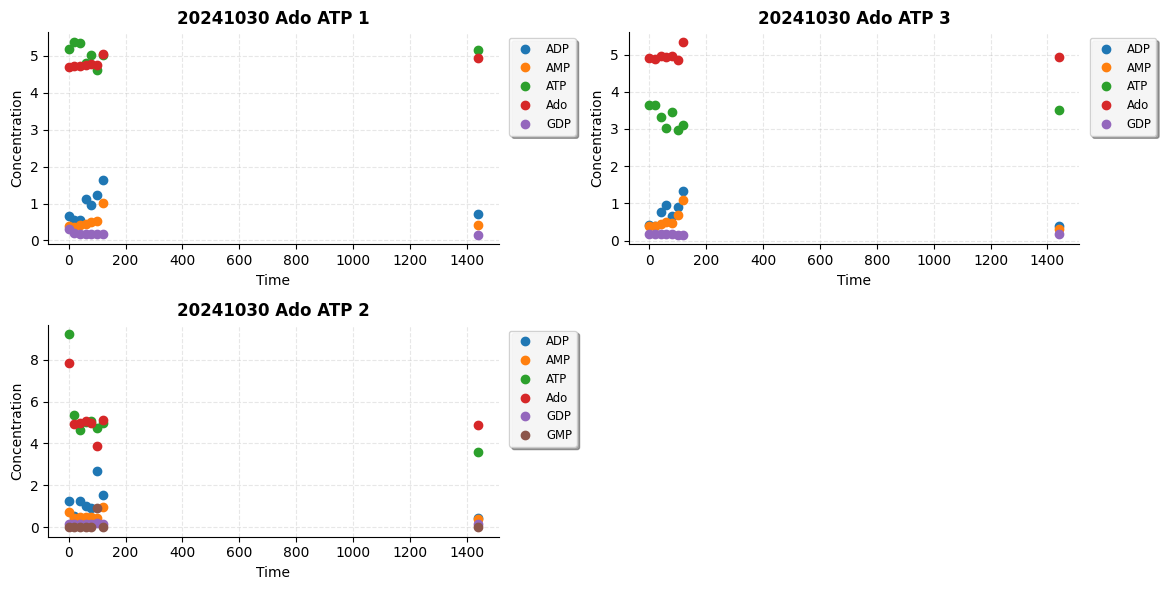

In [6]:
fig, ax = pe.plot(timecourse_enzymeML)

Furthermore, the `plot_replicates` function can be used to plot the replicates. It aggregates replicates and plots the mean±std per species as an errorbar plot. The function can be modified by manipulating the code in `utility/plot.py`.

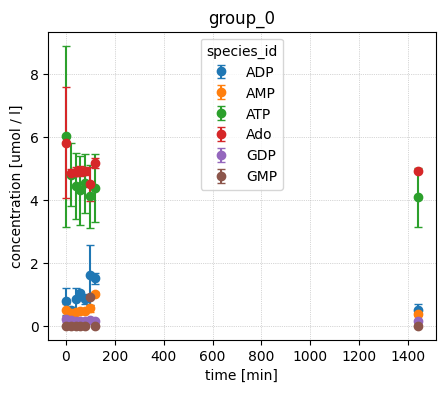

In [7]:
fig, axes = plot_replicates(timecourse_enzymeML)